In [2]:
import sys
from coffea.util import load
import matplotlib.pyplot as plt
from hist import Hist
import numpy as np 
import matplotlib.pyplot as plt
import coffea.hist as chist


/eos/user/p/piosifid/.local/lib/python3.11/site-packages/coffea/util.py:154: FutureWarning: In coffea version v2023.3.0 (target date: 31 Mar 2023), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


In [3]:
from scipy.stats import gamma
def poisson_asymmetric_errors(n, cl=0.6827):
    """
    Returns (lower_error, upper_error) for a Poisson count `n` using Garwood intervals.
    """
    alpha = 1 - cl
    lower = gamma.ppf(alpha / 2, n) if n > 0 else 0.0
    upper = gamma.ppf(1 - alpha / 2, n + 1)
    return n - lower, upper - n

Loading: /eos/home-i04/p/piosifid/PocketCoffea/ANN_newCoffea/CLEAN_050526/TRF_MC_2023_postBPix_noSF_NOCSF_050526//output_all.coffea
Processing histogram: Massreco_chosen_pair_higgs_mass_4
Lumi scaling: 9.68 → 109.95 fb⁻¹  (factor = 11.358)

Significance BEFORE closure correction : Z = 2.17227
Significance AFTER  closure correction : Z = 2.17227


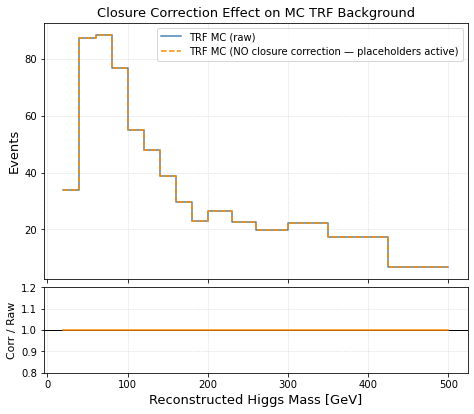

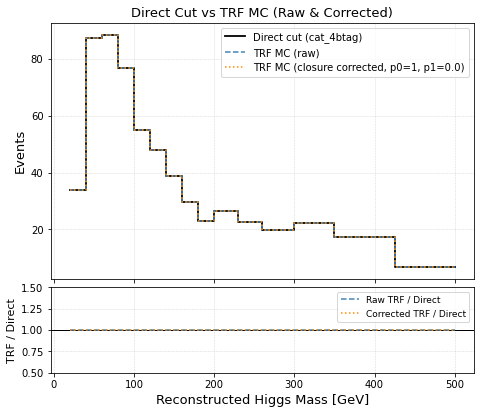

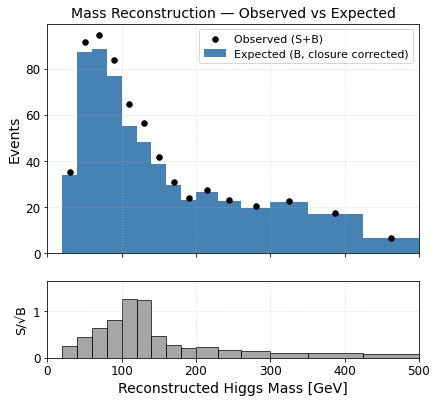

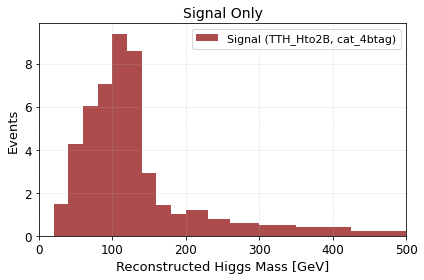


Done.


In [9]:
"""
Expected significance with pol1 closure correction on MC TRF background.

Closure correction form:  corrected_bin = raw_bin / (p0 + p1 * bin_center)

Replace P0_CLOSURE and P1_CLOSURE with your derived values.
"""

import numpy as np
import matplotlib.pyplot as plt
from coffea.util import load
from hist import Hist

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

COFFEA_PATH = "/eos/home-i04/p/piosifid/PocketCoffea/ANN_newCoffea/CLEAN_050526/TRF_MC_2023_postBPix_noSF_NOCSF_050526//output_all.coffea"

HIST_NAME   = "Massreco_chosen_pair_higgs_mass_4"

DATASET_CATS = {
    "TTH_Hto2B":  "cat_4btag",
    "TTTo2L2Nu":  "cat_4btag",   # MC TRF background
}

L_OLD = 9.68    # fb^-1  (luminosity the coffea file is normalized to)
L_NEW = 109.95   # fb^-1  (target luminosity)

X_CUT = 500     # GeV — upper mbb cut for plots and significance
X_CUT_LOW = 20  
REBIN_FACTOR = 1  # increase if you want coarser bins

# ─────────────────────────────────────────────
# CLOSURE CORRECTION PARAMETERS  ← swap these
# ─────────────────────────────────────────────
# Form:  correction(mbb) = 1 / (P0_CLOSURE + P1_CLOSURE * mbb)
# These are PLACEHOLDERS — replace with your Run 3 derived values.

#P0_CLOSURE = 0.714    # placeholder: no correction
P0_CLOSURE = 1
P1_CLOSURE = 0.000    # placeholder: no correction


# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def extract_hist(hist_container, dataset_name, cat):
    """Extract nominal 1D histogram for a given dataset and category."""
    if dataset_name not in hist_container:
        print(f"Dataset '{dataset_name}' not found.")
        return None
    for variation, hist in hist_container[dataset_name].items():
        if not isinstance(hist, Hist):
            continue
        if "cat" in [ax.name for ax in hist.axes]:
            hist = hist[{"cat": cat}]
        if "variation" in [ax.name for ax in hist.axes]:
            hist = hist[{"variation": "nominal"}]
        return hist
    return None


def rebin_1d(hist_obj, rebin_factor):
    """Rebin a 1D Hist object and return (edges, values)."""
    axis   = hist_obj.axes[0]
    edges  = axis.edges
    n_bins = len(edges) - 1

    if n_bins % rebin_factor != 0:
        raise ValueError(
            f"Rebin factor {rebin_factor} does not divide {n_bins} bins evenly."
        )

    new_edges = edges[::rebin_factor]
    if edges[-1] not in new_edges:
        new_edges = np.append(new_edges, edges[-1])

    old_vals     = hist_obj.values()[()]
    rebinned_vals = np.add.reduceat(old_vals, np.arange(0, len(old_vals), rebin_factor))

    return new_edges, rebinned_vals


def apply_pol1_closure(values, bin_centers, p0, p1):
    """
    Apply bin-by-bin pol1 closure correction.
    correction(mbb) = 1 / (p0 + p1 * mbb)
    Returns corrected values array (copy).
    """
    corrected = values.copy()
    for i, center in enumerate(bin_centers):
        denom = p0 + p1 * center
        if denom == 0:
            raise ValueError(
                f"Closure correction denominator is zero at bin center {center:.1f} GeV. "
                f"Check your p0/p1 values."
            )
        corrected[i] = values[i] / denom
    return corrected


def poisson_significance(signal_values, background_values):
    """
    Compute Poisson chi-squared significance:
    Z = sqrt( sum_bins 2*(mu - M + M*ln(M/mu)) )
    where M = S+B (observed), mu = B (expected background).
    """
    chi2 = 0.0
    for S, B in zip(signal_values, background_values):
        M  = S + B
        mu = B
        if mu > 0 and M > 0:
            chi2 += 2.0 * (mu - M + M * np.log(M / mu))
        elif M == 0:
            chi2 += 2.0 * mu
    return np.sqrt(chi2)


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def main():

    # --- Load coffea file ---
    print(f"Loading: {COFFEA_PATH}")
    hist_data = load(COFFEA_PATH)
    variables = hist_data.get("variables", {})

    if HIST_NAME not in variables:
        print(f"Histogram '{HIST_NAME}' not found in variables.")
        return

    print(f"Processing histogram: {HIST_NAME}")
    hist_container = variables[HIST_NAME]

    signal_hist     = extract_hist(hist_container, "TTH_Hto2B",  DATASET_CATS["TTH_Hto2B"])
    background_hist = extract_hist(hist_container, "TTTo2L2Nu",  DATASET_CATS["TTTo2L2Nu"])

    if signal_hist is None or background_hist is None:
        print("Error: could not retrieve both signal and background histograms.")
        return

    # --- Rebin ---
    new_edges,      signal_values     = rebin_1d(signal_hist,     REBIN_FACTOR)
    _,              background_values = rebin_1d(background_hist, REBIN_FACTOR)

    bin_centers = 0.5 * (new_edges[:-1] + new_edges[1:])
    bin_widths  = new_edges[1:]  - new_edges[:-1]

    # --- Luminosity scaling ---
    scaling_factor    = L_NEW / L_OLD
    signal_values     = signal_values     * scaling_factor
    background_values = background_values * scaling_factor
    print(f"Lumi scaling: {L_OLD} → {L_NEW} fb⁻¹  (factor = {scaling_factor:.3f})")

    # --- Closure correction on MC TRF background ---
    background_raw       = background_values.copy()   # keep uncorrected for comparison
    background_corrected = apply_pol1_closure(background_values, bin_centers, P0_CLOSURE, P1_CLOSURE)

    closure_label = (
        f"TRF MC (closure corrected)\n"
        f"p0={P0_CLOSURE}, p1={P1_CLOSURE}"
        if not (P0_CLOSURE == 1.0 and P1_CLOSURE == 0.0)
        else "TRF MC (NO closure correction — placeholders active)"
    )

    # --- Significance (before and after correction) ---
    sig_raw       = poisson_significance(signal_values, background_raw)
    sig_corrected = poisson_significance(signal_values, background_corrected)

    print(f"\nSignificance BEFORE closure correction : Z = {sig_raw:.5f}")
    print(f"Significance AFTER  closure correction : Z = {sig_corrected:.5f}")

    # --- Apply x cut for plots ---
    mask = (bin_centers >= X_CUT_LOW) #& (bin_centers <= X_CUT)
    bc   = bin_centers[mask]
    bw   = bin_widths[mask]
    sv   = signal_values[mask]
    bv_raw  = background_raw[mask]
    bv_corr = background_corrected[mask]
    obs  = sv + bv_corr
    pulls = np.where(bv_corr > 0, sv / np.sqrt(bv_corr), 0.0)

    # ─────────────────────────────────────────────
    # PLOT 1 — Closure correction effect on background
    # ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    axes[0].step(np.append(bc - bw/2, bc[-1] + bw[-1]/2),
                 np.append(bv_raw, bv_raw[-1]),
                 where="post", color="steelblue", lw=1.5, label="TRF MC (raw)")
    axes[0].step(np.append(bc - bw/2, bc[-1] + bw[-1]/2),
                 np.append(bv_corr, bv_corr[-1]),
                 where="post", color="darkorange", lw=1.5, ls="--",
                 label=closure_label)
    axes[0].set_ylabel("Events", fontsize=13)
    axes[0].set_title("Closure Correction Effect on MC TRF Background", fontsize=13)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, ls="--", lw=0.5, alpha=0.5)

    ratio = np.where(bv_raw > 0, bv_corr / bv_raw, 1.0)
    axes[1].axhline(1, color="black", lw=1)
    axes[1].step(np.append(bc - bw/2, bc[-1] + bw[-1]/2),
                 np.append(ratio, ratio[-1]),
                 where="post", color="darkorange", lw=1.5)
    axes[1].set_ylabel("Corr / Raw", fontsize=11)
    axes[1].set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
    axes[1].set_ylim(0.8, 1.2)
    axes[1].grid(True, ls="--", lw=0.5, alpha=0.5)

    fig.subplots_adjust(left=0.12, right=0.96, top=0.93, bottom=0.12, hspace=0.05)
    plt.show()
    # ─────────────────────────────────────────────
    # PLOT 1b — Raw TRF vs Corrected TRF vs Direct cut
    # ─────────────────────────────────────────────

    # Extract the direct cat_4btag background from the same file
    background_direct_hist = extract_hist(hist_container, "TTTo2L2Nu", "cat_4btag")

    if background_direct_hist is None:
        print("Warning: could not retrieve cat_4btag direct histogram — skipping Plot 1b.")
    else:
        _, background_direct_values = rebin_1d(background_direct_hist, REBIN_FACTOR)
        background_direct_values = background_direct_values * scaling_factor

        bv_direct = background_direct_values[mask]

        fig1b, axes1b = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                                     gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

        # --- Top panel ---
        axes1b[0].step(np.append(bc - bw/2, bc[-1] + bw[-1]/2),
                       np.append(bv_direct, bv_direct[-1]),
                       where="post", color="black", lw=1.8, label="Direct cut (cat_4btag)")
        axes1b[0].step(np.append(bc - bw/2, bc[-1] + bw[-1]/2),
                       np.append(bv_raw, bv_raw[-1]),
                       where="post", color="steelblue", lw=1.5, ls="--", label="TRF MC (raw)")
        axes1b[0].step(np.append(bc - bw/2, bc[-1] + bw[-1]/2),
                       np.append(bv_corr, bv_corr[-1]),
                       where="post", color="darkorange", lw=1.5, ls=":",
                       label=f"TRF MC (closure corrected, p0={P0_CLOSURE}, p1={P1_CLOSURE})")

        axes1b[0].set_ylabel("Events", fontsize=13)
        axes1b[0].set_title("Direct Cut vs TRF MC (Raw & Corrected)", fontsize=13)
        axes1b[0].legend(fontsize=10)
        axes1b[0].grid(True, ls="--", lw=0.5, alpha=0.5)

        # --- Bottom panel: ratios over direct ---
        ratio_raw  = np.where(bv_direct > 0, bv_raw  / bv_direct, 1.0)
        ratio_corr = np.where(bv_direct > 0, bv_corr / bv_direct, 1.0)

        axes1b[1].axhline(1, color="black", lw=1)
        axes1b[1].step(np.append(bc - bw/2, bc[-1] + bw[-1]/2),
                       np.append(ratio_raw, ratio_raw[-1]),
                       where="post", color="steelblue", lw=1.5, ls="--", label="Raw TRF / Direct")
        axes1b[1].step(np.append(bc - bw/2, bc[-1] + bw[-1]/2),
                       np.append(ratio_corr, ratio_corr[-1]),
                       where="post", color="darkorange", lw=1.5, ls=":", label="Corrected TRF / Direct")

        axes1b[1].set_ylabel("TRF / Direct", fontsize=11)
        axes1b[1].set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
        axes1b[1].set_ylim(0.5, 1.5)
        axes1b[1].legend(fontsize=9)
        axes1b[1].grid(True, ls="--", lw=0.5, alpha=0.5)

        fig1b.subplots_adjust(left=0.12, right=0.96, top=0.93, bottom=0.12, hspace=0.05)
        plt.show()
    # ─────────────────────────────────────────────
    # PLOT 2 — Observed vs Expected (with corrected background)
    # ─────────────────────────────────────────────
    fig2 = plt.figure(figsize=(6, 6))
    gs2  = fig2.add_gridspec(4, 1, height_ratios=[3, 0.15, 1, 0.1], hspace=0.1)
    ax_top    = fig2.add_subplot(gs2[0])
    ax_bottom = fig2.add_subplot(gs2[2], sharex=ax_top)

    ax_top.bar(bc, bv_corr, width=bw, label="Expected (B, closure corrected)",
               color="steelblue", linewidth=1, align="center")
    ax_top.scatter(bc, obs, label="Observed (S+B)", color="black",
                   marker="o", s=30, zorder=3)
    ax_top.set_ylabel("Events", fontsize=14)
    ax_top.set_title("Mass Reconstruction — Observed vs Expected", fontsize=14)
    ax_top.legend(fontsize=11, loc="upper right")
    ax_top.set_xlim(0, X_CUT)
    ax_top.grid(True, ls="--", lw=0.5, alpha=0.5)
    plt.setp(ax_top.get_xticklabels(), visible=False)

    ax_bottom.axhline(0, color="black", lw=1)
    ax_bottom.bar(bc, pulls, width=bw, color="gray", edgecolor="black", alpha=0.7)
    ax_bottom.set_ylabel("S/√B", fontsize=13)
    ax_bottom.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=14)
    ax_bottom.set_ylim(0, max(pulls.max() * 1.3, 0.1))
    ax_bottom.set_xlim(0, X_CUT)
    ax_bottom.grid(True, ls="--", lw=0.5, alpha=0.5)

    for ax in [ax_top, ax_bottom]:
        ax.tick_params(axis="both", labelsize=12)

    fig2.subplots_adjust(left=0.1, right=0.96, top=0.93, bottom=0.12, hspace=0.03)

    sig_text = (
        f"Z (raw)      = {sig_raw:.3f}\n"
        f"Z (corrected)= {sig_corrected:.3f}"
    )
    #ax_top.text(0.03, 0.97, sig_text, transform=ax_top.transAxes,
            #    fontsize=9, va="top", family="monospace",
             #   bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    plt.show()

    # ─────────────────────────────────────────────
    # PLOT 3 — Signal only
    # ─────────────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(6, 4))
    ax3.bar(bc, sv, width=bw, color="darkred", alpha=0.7,
            label=f"Signal (TTH_Hto2B, {DATASET_CATS['TTH_Hto2B']})", align="center")
    ax3.set_title("Signal Only", fontsize=14)
    ax3.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
    ax3.set_ylabel("Events", fontsize=13)
    ax3.set_xlim(0, X_CUT)
    ax3.grid(True, ls="--", lw=0.5, alpha=0.5)
    ax3.legend(fontsize=11)
    ax3.tick_params(axis="both", labelsize=12)
    plt.tight_layout()
    plt.show()

    print("\nDone.")


if __name__ == "__main__":
    main()


Available keys: dict_keys(['sum_genweights', 'sum_signOf_genweights', 'sumw', 'sumw2', 'cutflow', 'variables', 'columns', 'processing_metadata', 'datasets_metadata'])

Processing histogram: Massreco_chosen_pair_higgs_mass_4
  Dataset: TTTo2L2Nu, Variation: TTTo2L2Nu_2024

Bin entries (center): count
  (10.00): 0.33
  (30.00): 61.06
  (50.00): 126.97
  (70.00): 133.59
  (90.00): 121.15
  (110.00): 99.39
  (130.00): 76.52
  (150.00): 61.71
  (170.00): 47.54
  (190.00): 36.19
  (215.00): 42.37
  (245.00): 28.96
  (280.00): 29.22
  (325.00): 29.29
  (387.50): 25.86
  (462.50): 16.31
  Integral (sum of all counts): 936.49
  Dataset: TTH_Hto2B, Variation: TTH_Hto2B_2024

Bin entries (center): count
  (10.00): 0.01
  (30.00): 1.70
  (50.00): 6.56
  (70.00): 10.24
  (90.00): 11.00
  (110.00): 16.36
  (130.00): 15.42
  (150.00): 5.06
  (170.00): 2.75
  (190.00): 1.64
  (215.00): 1.73
  (245.00): 1.10
  (280.00): 0.89
  (325.00): 0.75
  (387.50): 0.50
  (462.50): 0.25
  Integral (sum of all coun

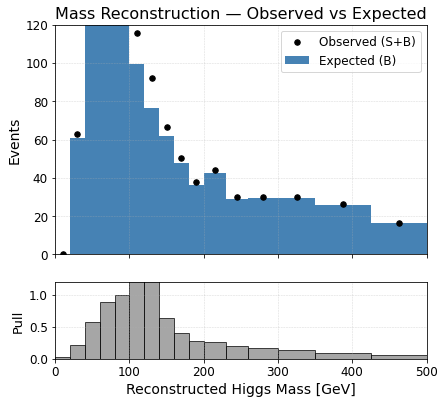

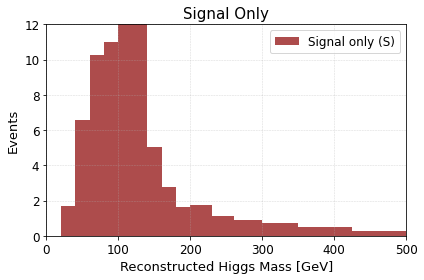

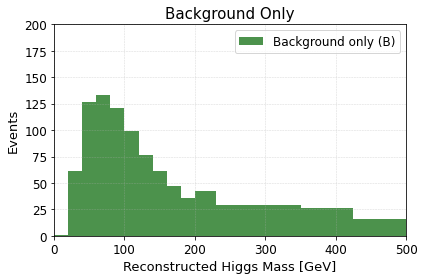


Bin-wise Complex Significance (Z_A):
Poisson Chi-squared (same bins): sqrt(χ²) = 2.89698


In [6]:
import sys
from coffea.util import load
import matplotlib.pyplot as plt
from hist import Hist
import numpy as np 
import matplotlib.pyplot as plt
import coffea.hist as chist

hist_data = load("/eos/home-i04/p/piosifid/PocketCoffea/ANN_newCoffea/DATA_MassReco/22May_bkg_test/output_all.coffea")
print("Available keys:", hist_data.keys())

variables = hist_data.get("variables", {})
#hist_name = "m_higgs_like_jj"
hist_name = "Massreco_chosen_pair_higgs_mass_4"
#hist_name = "Max_Weight_Higgs_Mass"
#hist_name = "nBJets"
if hist_name in variables:
    print(f"\nProcessing histogram: {hist_name}")
    
    hist_container = variables[hist_name]
    
    for dataset, hist_dict in hist_container.items():
        for variation, hist in hist_dict.items():
            print(f"  Dataset: {dataset}, Variation: {variation}")
            
            if not isinstance(hist, Hist):
                print(f"    Skipping {hist_name} - Not a valid Hist object")
                continue
            
            # Handle 'cat' axis
            if "cat" in [axis.name for axis in hist.axes]:
                hist = hist[{"cat": "baseline_all_atleast4bjets"}]

            # Handle 'variation' axis
            if "variation" in [axis.name for axis in hist.axes]:
                hist = hist[{"variation": "nominal"}]
                
            # Handle 1D histograms
            if len(hist.axes) == 1:
                edges = hist.axes[0].edges  # Bin edges
                values = hist.values()      # Bin values
                sum_entries = 0
                
                print("\nBin entries (center): count")
                for i in range(len(edges) - 1):
                    center = 0.5 * (edges[i] + edges[i + 1])
                    count = values[i]
                    sum_entries += count
                    print(f"  ({center:.2f}): {count:.2f}")
                
                print(f"  Integral (sum of all counts): {sum_entries:.2f}")

else:
    print(f"Histogram '{hist_name}' not found in variables.")
    



def rebin_1d_hist_manual(hist_obj, rebin_factor):
    axis = hist_obj.axes[0]
    edges = axis.edges
    n_bins = len(edges) - 1

    if n_bins % rebin_factor != 0:
        raise ValueError(f"Rebin factor {rebin_factor} does not divide {n_bins} bins evenly.")

    new_edges = edges[::rebin_factor]
    if edges[-1] not in new_edges:
        new_edges = np.append(new_edges, edges[-1])

    old_vals = hist_obj.values()[()]
    rebinned_vals = np.add.reduceat(old_vals, np.arange(0, len(old_vals), rebin_factor))

    return new_edges, rebinned_vals





if hist_name in variables:
    print(f"\nProcessing histogram: {hist_name}")

    hist_container = variables[hist_name]

    signal_dataset = "TTH_Hto2B"
    background_dataset = "TTTo2L2Nu"

    signal_hist = None
    background_hist = None
    

    # Extract histograms for signal and background
    for dataset, hist_dict in hist_container.items():
        for variation, hist in hist_dict.items():
            if not isinstance(hist, Hist):
                continue
            
            # Handle 'cat' axis
            if "cat" in [axis.name for axis in hist.axes]:
                hist = hist[{"cat": "baseline_all_atleast4bjets" }]

            # Handle 'variation' axis
            if "variation" in [axis.name for axis in hist.axes]:
                hist = hist[{"variation": "nominal"}]

            if dataset == signal_dataset:
                signal_hist = hist
            elif dataset == background_dataset:
                background_hist = hist

    # Ensure we have both histograms
    if signal_hist is None or background_hist is None:
        print("Error: Could not find both signal and background histograms.")
    else:
        print("Number of bins:", len(signal_hist.axes[0].edges) - 1)
        new_edges, signal_values = rebin_1d_hist_manual(signal_hist, rebin_factor=1)
        _, background_values = rebin_1d_hist_manual(background_hist, rebin_factor=1)

        bin_centers = 0.5 * (new_edges[:-1] + new_edges[1:])
        bin_widths = new_edges[1:] - new_edges[:-1]

        # === Add this block for rescaling to new luminosity ===
        L_old = 9.68  # fb^-1 (original luminosity from your plot)
        L_new = 250  # fb^-1 (target luminosity you want to scale to)
        #scaling_factor = L_new / L_old
        scaling_factor = 1
        print(f"\nScaling histograms from {L_old} fb⁻¹ to {L_new} fb⁻¹ (factor = {scaling_factor:.3f})")

        # Apply scaling to the bin contents
        signal_values *= scaling_factor
        background_values *= scaling_factor
        # =======================================================
        # Compute observed (signal + background) and pulls
        observed_values = signal_values + background_values
        expected_values = background_values  
        significance_values = []
        bin_centers = 0.5 * (new_edges[:-1] + new_edges[1:])
        bin_widths = new_edges[1:] - new_edges[:-1]
        
        # Compute pulls
        pulls = np.zeros_like(signal_values)
        for i in range(len(signal_values)):
           S = signal_values[i]
           B = background_values[i]
           pulls[i] = S / np.sqrt(B) if B > 0 else 0.0
        x_cut = 500
        mask = bin_centers <= x_cut

        # Slice values
        bin_centers = bin_centers[mask]
        bin_widths = bin_widths[mask]
        observed_values = observed_values[mask]
        expected_values = expected_values[mask]
        pulls = pulls[mask]
        # --- CMS-style Plot with Fixed Aesthetics ---
        fig = plt.figure(figsize=(6, 6))
        gs = fig.add_gridspec(4, 1, height_ratios=[3, 0.15, 1, 0.1], hspace=0.1)
        ax_top = fig.add_subplot(gs[0])
        ax_bottom = fig.add_subplot(gs[2], sharex=ax_top)

        # --- Top Panel: Histogram ---
        ax_top.bar(bin_centers, expected_values, width=bin_widths,
           label='Expected (B)', color='steelblue', linewidth=1, align='center')

        ax_top.scatter(bin_centers, observed_values, label='Observed (S+B)', color='black', marker='o', s=30, zorder=3)

        ax_top.set_ylabel("Events", fontsize=14)
        ax_top.set_title("Mass Reconstruction — Observed vs Expected", fontsize=16)
        ax_top.legend(fontsize=12, loc="upper right")
        ax_top.set_xlim(0, 500)
        ax_top.set_ylim(0, 120)
        ax_top.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

        # --- Bottom Panel: Pulls ---
        ax_bottom.axhline(0, color='black', linewidth=1)
        ax_bottom.bar(bin_centers, pulls, width=bin_widths, color='gray',  edgecolor='black', alpha=0.7)

        ax_bottom.set_ylabel("Pull", fontsize=13)
        ax_bottom.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=14)
        ax_bottom.set_ylim(0, 1.2)
        ax_bottom.set_xlim(0, 500)
        ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

        plt.setp(ax_top.get_xticklabels(), visible=False)

        for ax in [ax_top, ax_bottom]:
            ax.tick_params(axis='both', labelsize=12)

        fig.subplots_adjust(left=0.1, right=0.96, top=0.93, bottom=0.12, hspace=0.03)
        plt.show()
        signal_values_msk = signal_values[mask]
        background_values_msk = background_values[mask]
        # === Plot Signal-Only Histogram ===
        fig_signal = plt.figure(figsize=(6, 4))
        ax_signal = fig_signal.add_subplot(111)
        ax_signal.bar(bin_centers, signal_values_msk, width=bin_widths, color='darkred'
                     , alpha=0.7, label='Signal only (S)', align='center')

        ax_signal.set_title("Signal Only", fontsize=15)
        ax_signal.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
        ax_signal.set_ylabel("Events", fontsize=13)
        ax_signal.set_xlim(0, 500)
        ax_signal.set_ylim(0, 12)
        ax_signal.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
        ax_signal.legend(fontsize=12)
        ax_signal.tick_params(axis='both', labelsize=12)
        plt.tight_layout()
        plt.show()

        # === Plot Background-Only Histogram ===
        fig_background = plt.figure(figsize=(6, 4))
        ax_background = fig_background.add_subplot(111)
        ax_background.bar(bin_centers, background_values_msk, width=bin_widths, color='darkgreen'
                  , alpha=0.7, label='Background only (B)', align='center')

        ax_background.set_title("Background Only", fontsize=15)
        ax_background.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
        ax_background.set_ylabel("Events", fontsize=13)
        ax_background.set_xlim(0, 500)
        ax_background.set_ylim(0, 200)
        ax_background.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
        ax_background.legend(fontsize=12)
        ax_background.tick_params(axis='both', labelsize=12)
        plt.tight_layout()
        plt.show()
        chi2_poisson = 0  
        s = 0
        print("\nBin-wise Complex Significance (Z_A):")
        for i in range(len(new_edges) - 1):
            S = signal_values[i]
            B = background_values[i]
            M = S + B  # Asimov data
            mu = B  

            if mu > 0 and M > 0:
              Z = 2 * (mu - M + M * np.log(M / mu))
              chi2_poisson += Z  
            elif M == 0:
              Z = 2 * mu
              chi2_poisson += Z  
            else:
              Z = 0  # Avoid invalid values

        
        s = np.sqrt(chi2_poisson)
       
        print(f"Poisson Chi-squared (same bins): sqrt(χ²) = {s:.5f}")

else:
    print(f"Histogram '{hist_name}' not found in variables.")

Available keys: dict_keys(['sum_genweights', 'sum_signOf_genweights', 'sumw', 'sumw2', 'cutflow', 'variables', 'columns', 'processing_metadata', 'datasets_metadata'])

Processing histogram: Massreco_chosen_pair_higgs_mass_4
  Dataset: TTTo2L2Nu, Variation: TTTo2L2Nu_2023_postBPix

Bin entries (center): count
  (10.00): 0.00
  (30.00): 2.99
  (50.00): 7.69
  (70.00): 7.81
  (90.00): 6.76
  (110.00): 4.85
  (130.00): 4.23
  (150.00): 3.42
  (170.00): 2.60
  (190.00): 2.02
  (215.00): 2.33
  (245.00): 1.98
  (280.00): 1.75
  (325.00): 1.94
  (387.50): 1.51
  (462.50): 0.58
  Integral (sum of all counts): 52.47
  Dataset: TTH_Hto2B, Variation: TTH_Hto2B_2023_postBPix

Bin entries (center): count
  (10.00): 0.00
  (30.00): 0.13
  (50.00): 0.37
  (70.00): 0.53
  (90.00): 0.62
  (110.00): 0.83
  (130.00): 0.75
  (150.00): 0.26
  (170.00): 0.13
  (190.00): 0.09
  (215.00): 0.11
  (245.00): 0.07
  (280.00): 0.05
  (325.00): 0.04
  (387.50): 0.04
  (462.50): 0.02
  Integral (sum of all counts): 

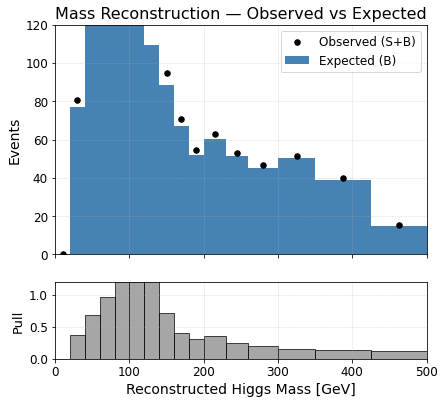

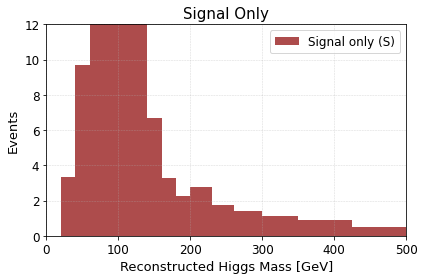

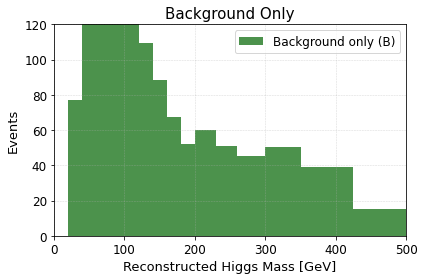


Bin-wise Complex Significance (Z_A):
Poisson Chi-squared (same bins): sqrt(χ²) = 3.27556


In [10]:
hist_data = load("/eos/user/p/piosifid/PocketCoffea/ANN_newCoffea/INF_DNN_new/sign_0505/output_all.coffea")
print("Available keys:", hist_data.keys())

variables = hist_data.get("variables", {})
#hist_name = "m_higgs_like_jj"
hist_name = "Massreco_chosen_pair_higgs_mass_4"
#hist_name = "Max_Weight_Higgs_Mass"
#hist_name = "nBJets"
if hist_name in variables:
    print(f"\nProcessing histogram: {hist_name}")
    
    hist_container = variables[hist_name]
    
    for dataset, hist_dict in hist_container.items():
        for variation, hist in hist_dict.items():
            print(f"  Dataset: {dataset}, Variation: {variation}")
            
            if not isinstance(hist, Hist):
                print(f"    Skipping {hist_name} - Not a valid Hist object")
                continue
            
            # Handle 'cat' axis
            if "cat" in [axis.name for axis in hist.axes]:
                hist = hist[{"cat": "baseline_all_atleast4bjets"}]

            # Handle 'variation' axis
            if "variation" in [axis.name for axis in hist.axes]:
                hist = hist[{"variation": "nominal"}]
                
            # Handle 1D histograms
            if len(hist.axes) == 1:
                edges = hist.axes[0].edges  # Bin edges
                values = hist.values()      # Bin values
                sum_entries = 0
                
                print("\nBin entries (center): count")
                for i in range(len(edges) - 1):
                    center = 0.5 * (edges[i] + edges[i + 1])
                    count = values[i]
                    sum_entries += count
                    print(f"  ({center:.2f}): {count:.2f}")
                
                print(f"  Integral (sum of all counts): {sum_entries:.2f}")

else:
    print(f"Histogram '{hist_name}' not found in variables.")
    



def rebin_1d_hist_manual(hist_obj, rebin_factor):
    axis = hist_obj.axes[0]
    edges = axis.edges
    n_bins = len(edges) - 1

    if n_bins % rebin_factor != 0:
        raise ValueError(f"Rebin factor {rebin_factor} does not divide {n_bins} bins evenly.")

    new_edges = edges[::rebin_factor]
    if edges[-1] not in new_edges:
        new_edges = np.append(new_edges, edges[-1])

    old_vals = hist_obj.values()[()]
    rebinned_vals = np.add.reduceat(old_vals, np.arange(0, len(old_vals), rebin_factor))

    return new_edges, rebinned_vals





if hist_name in variables:
    print(f"\nProcessing histogram: {hist_name}")

    hist_container = variables[hist_name]

    signal_dataset = "TTH_Hto2B"
    background_dataset = "TTTo2L2Nu"

    signal_hist = None
    background_hist = None
    

    # Extract histograms for signal and background
    for dataset, hist_dict in hist_container.items():
        for variation, hist in hist_dict.items():
            if not isinstance(hist, Hist):
                continue
            
            # Handle 'cat' axis
            if "cat" in [axis.name for axis in hist.axes]:
                hist = hist[{"cat": "baseline_all_atleast4bjets" }]

            # Handle 'variation' axis
            if "variation" in [axis.name for axis in hist.axes]:
                hist = hist[{"variation": "nominal"}]

            if dataset == signal_dataset:
                signal_hist = hist
            elif dataset == background_dataset:
                background_hist = hist

    # Ensure we have both histograms
    if signal_hist is None or background_hist is None:
        print("Error: Could not find both signal and background histograms.")
    else:
        print("Number of bins:", len(signal_hist.axes[0].edges) - 1)
        new_edges, signal_values = rebin_1d_hist_manual(signal_hist, rebin_factor=1)
        _, background_values = rebin_1d_hist_manual(background_hist, rebin_factor=1)

        bin_centers = 0.5 * (new_edges[:-1] + new_edges[1:])
        bin_widths = new_edges[1:] - new_edges[:-1]

        # === Add this block for rescaling to new luminosity ===
        L_old = 9.68  # fb^-1 (original luminosity from your plot)
        L_new = 250  # fb^-1 (target luminosity you want to scale to)
        scaling_factor = L_new / L_old
        #scaling_factor = 1
        print(f"\nScaling histograms from {L_old} fb⁻¹ to {L_new} fb⁻¹ (factor = {scaling_factor:.3f})")

        # Apply scaling to the bin contents
        signal_values *= scaling_factor
        background_values *= scaling_factor
        # =======================================================
        # Compute observed (signal + background) and pulls
        observed_values = signal_values + background_values
        expected_values = background_values  
        significance_values = []
        bin_centers = 0.5 * (new_edges[:-1] + new_edges[1:])
        bin_widths = new_edges[1:] - new_edges[:-1]
        
        # Compute pulls
        pulls = np.zeros_like(signal_values)
        for i in range(len(signal_values)):
           S = signal_values[i]
           B = background_values[i]
           pulls[i] = S / np.sqrt(B) if B > 0 else 0.0
        x_cut = 500
        mask = bin_centers <= x_cut

        # Slice values
        bin_centers = bin_centers[mask]
        bin_widths = bin_widths[mask]
        observed_values = observed_values[mask]
        expected_values = expected_values[mask]
        pulls = pulls[mask]
        # --- CMS-style Plot with Fixed Aesthetics ---
        fig = plt.figure(figsize=(6, 6))
        gs = fig.add_gridspec(4, 1, height_ratios=[3, 0.15, 1, 0.1], hspace=0.1)
        ax_top = fig.add_subplot(gs[0])
        ax_bottom = fig.add_subplot(gs[2], sharex=ax_top)

        # --- Top Panel: Histogram ---
        ax_top.bar(bin_centers, expected_values, width=bin_widths,
           label='Expected (B)', color='steelblue', linewidth=1, align='center')

        ax_top.scatter(bin_centers, observed_values, label='Observed (S+B)', color='black', marker='o', s=30, zorder=3)

        ax_top.set_ylabel("Events", fontsize=14)
        ax_top.set_title("Mass Reconstruction — Observed vs Expected", fontsize=16)
        ax_top.legend(fontsize=12, loc="upper right")
        ax_top.set_xlim(0, 500)
        ax_top.set_ylim(0, 120)
        ax_top.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

        # --- Bottom Panel: Pulls ---
        ax_bottom.axhline(0, color='black', linewidth=1)
        ax_bottom.bar(bin_centers, pulls, width=bin_widths, color='gray',  edgecolor='black', alpha=0.7)

        ax_bottom.set_ylabel("Pull", fontsize=13)
        ax_bottom.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=14)
        ax_bottom.set_ylim(0, 1.2)
        ax_bottom.set_xlim(0, 500)
        ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

        plt.setp(ax_top.get_xticklabels(), visible=False)

        for ax in [ax_top, ax_bottom]:
            ax.tick_params(axis='both', labelsize=12)

        fig.subplots_adjust(left=0.1, right=0.96, top=0.93, bottom=0.12, hspace=0.03)
        plt.show()
        signal_values_msk = signal_values[mask]
        background_values_msk = background_values[mask]
        # === Plot Signal-Only Histogram ===
        fig_signal = plt.figure(figsize=(6, 4))
        ax_signal = fig_signal.add_subplot(111)
        ax_signal.bar(bin_centers, signal_values_msk, width=bin_widths, color='darkred'
                     , alpha=0.7, label='Signal only (S)', align='center')

        ax_signal.set_title("Signal Only", fontsize=15)
        ax_signal.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
        ax_signal.set_ylabel("Events", fontsize=13)
        ax_signal.set_xlim(0, 500)
        ax_signal.set_ylim(0, 12)
        ax_signal.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
        ax_signal.legend(fontsize=12)
        ax_signal.tick_params(axis='both', labelsize=12)
        plt.tight_layout()
        plt.show()

        # === Plot Background-Only Histogram ===
        fig_background = plt.figure(figsize=(6, 4))
        ax_background = fig_background.add_subplot(111)
        ax_background.bar(bin_centers, background_values_msk, width=bin_widths, color='darkgreen'
                  , alpha=0.7, label='Background only (B)', align='center')

        ax_background.set_title("Background Only", fontsize=15)
        ax_background.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
        ax_background.set_ylabel("Events", fontsize=13)
        ax_background.set_xlim(0, 500)
        ax_background.set_ylim(0, 120)
        ax_background.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
        ax_background.legend(fontsize=12)
        ax_background.tick_params(axis='both', labelsize=12)
        plt.tight_layout()
        plt.show()
        chi2_poisson = 0  
        s = 0
        print("\nBin-wise Complex Significance (Z_A):")
        for i in range(len(new_edges) - 1):
            S = signal_values[i]
            B = background_values[i]
            M = S + B  # Asimov data
            mu = B  

            if mu > 0 and M > 0:
              Z = 2 * (mu - M + M * np.log(M / mu))
              chi2_poisson += Z  
            elif M == 0:
              Z = 2 * mu
              chi2_poisson += Z  
            else:
              Z = 0  # Avoid invalid values

        
        s = np.sqrt(chi2_poisson)
       
        print(f"Poisson Chi-squared (same bins): sqrt(χ²) = {s:.5f}")

else:
    print(f"Histogram '{hist_name}' not found in variables.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Compute Poisson errors for observed
observed_errors = np.sqrt(observed_values)

# Compute (Observed - Expected) / σ_observed for lower panel
sigma_observed = observed_errors
diff_norm = (observed_values - expected_values) / sigma_observed
# Handle divisions by zero (when σ_observed = 0)
diff_norm = np.where(sigma_observed > 0, diff_norm, 0.0)

# === CMS-like Plot ===
fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(4, 1, height_ratios=[3, 0.15, 1, 0.1], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[2], sharex=ax_top)

# --- Top Panel ---
# Background as step-filled histogram
ax_top.hist(
    bin_centers, bins=new_edges, weights=expected_values,
    histtype='stepfilled', color='slateblue', alpha=0.5, label='Background', edgecolor='black', linewidth=1.2
)

# Observed as black points with error bars
ax_top.errorbar(
    bin_centers, observed_values, yerr=observed_errors,
    fmt='o', color='black', label='Data', markersize=5, capsize=2, zorder=3
)

# CMS Title and Lumi text
ax_top.text(0.02, 0.95, r"CMS Simulation", transform=ax_top.transAxes,
            fontsize=14, fontweight='bold', ha='left', va='top')
ax_top.text(0.02, 0.88, r"Preliminary", transform=ax_top.transAxes,
            fontsize=12, style='italic', ha='left', va='top')
ax_top.text(0.98, 0.95, r"140 fb$^{-1}$ (13 TeV)", transform=ax_top.transAxes,
            fontsize=12, ha='right', va='top')

# Styling
ax_top.set_ylabel("Number of events / bin width", fontsize=13)
ax_top.legend(fontsize=11, loc="best", frameon=False)
ax_top.set_xlim(0, 500)
ax_top.set_ylim(0, 1.2 * np.max(observed_values))
ax_top.tick_params(axis='both', labelsize=11)
ax_top.set_xticklabels([])  # Remove x-axis labels on top

# No grid in top panel (CMS style)
ax_top.grid(False)

# --- Bottom Panel ---
ax_bottom.axhline(0, color='black', linewidth=1)
ax_bottom.bar(
    bin_centers, diff_norm, width=bin_widths, color='brown', edgecolor='black', alpha=0.7
)

# Styling
ax_bottom.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
ax_bottom.set_ylabel(r'$(O - E)/\sigma_O$', fontsize=13)
ax_bottom.set_ylim(-1, 1)
ax_bottom.set_xlim(0, 500)
ax_bottom.tick_params(axis='both', labelsize=11)

# Add light grid only to bottom panel
ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)

# Final adjust
fig.subplots_adjust(left=0.12, right=0.96, top=0.93, bottom=0.12, hspace=0.03)
plt.show()


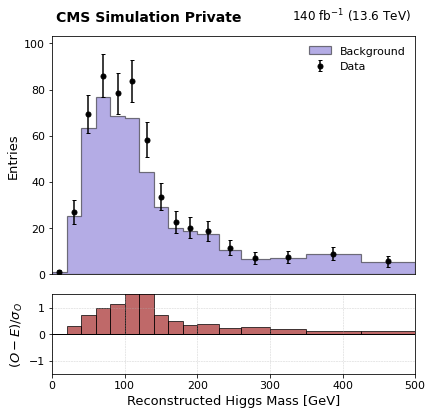


Bin-wise Complex Significance (Z_A):

Bin-wise Complex Significance (Z_A):
  Bin Center (10.00): Z = 0.016
  Bin Center (30.00): Z = 0.316
  Bin Center (50.00): Z = 0.756
  Bin Center (70.00): Z = 1.017
  Bin Center (90.00): Z = 1.182
  Bin Center (110.00): Z = 1.853
  Bin Center (130.00): Z = 2.030
  Bin Center (150.00): Z = 0.776
  Bin Center (170.00): Z = 0.525
  Bin Center (190.00): Z = 0.350
  Bin Center (215.00): Z = 0.375
  Bin Center (245.00): Z = 0.254
  Bin Center (280.00): Z = 0.285
  Bin Center (325.00): Z = 0.198
  Bin Center (387.50): Z = 0.115
  Bin Center (462.50): Z = 0.115

Poisson Chi-squared (same bins): sqrt(χ²) = 3.46550


In [27]:
# === CMS-like Plot FINAL POLISHED ===
fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(4, 1, height_ratios=[3, 0.15, 1, 0.1], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[2], sharex=ax_top)

# --- Top Panel ---
# Background as step-filled histogram
ax_top.hist(
    bin_centers, bins=new_edges, weights=expected_values,
    histtype='stepfilled', color='slateblue', alpha=0.5,
    label='Background', edgecolor='black', linewidth=1.2, zorder=1
)

# Observed as black points with error bars
ax_top.errorbar(
    bin_centers, observed_values, yerr=observed_errors,
    fmt='o', color='black', label='Data', markersize=5, capsize=2, zorder=3
)

# CMS Title and Lumi text (outside plot so it doesn't collide with legend)
ax_top.text(0.01, 1.05, r"CMS Simulation Private", transform=ax_top.transAxes,
            fontsize=14, fontweight='bold', ha='left', va='bottom')
ax_top.text(0.01, 0.98, r"", transform=ax_top.transAxes,
            fontsize=12, style='italic', ha='left', va='bottom')
ax_top.text(0.99, 1.05, r"140 fb$^{-1}$ (13.6 TeV)", transform=ax_top.transAxes,
            fontsize=12, ha='right', va='bottom')

# Styling
ax_top.set_ylabel("Entries", fontsize=13)
ax_top.legend(fontsize=11, loc="best", frameon=False)
ax_top.set_xlim(0, 500)
ax_top.set_ylim(0, 1.2 * np.max(observed_values))
ax_top.tick_params(axis='both', labelsize=11)
ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False) # Remove x-axis labels on top

# No grid in top panel (CMS style)
ax_top.grid(False)

# --- Bottom Panel ---
ax_bottom.axhline(0, color='black', linewidth=1)
ax_bottom.bar(
    bin_centers, diff_norm, width=bin_widths, color='brown',
    edgecolor='black', alpha=0.7
)

# Styling
ax_bottom.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
ax_bottom.set_ylabel(r'$(O - E)/\sigma_O$', fontsize=13)
ax_bottom.set_ylim(-1.5, 1.5)
ax_bottom.set_xlim(0, 500)
ax_bottom.tick_params(axis='both', labelsize=11)

# Light dashed grid only in bottom panel
ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)

# Final adjust
fig.subplots_adjust(left=0.12, right=0.96, top=0.93, bottom=0.12, hspace=0.03)
plt.show()
chi2_poisson = 0  
s = 0
print("\nBin-wise Complex Significance (Z_A):")
chi2_poisson = 0
significance_values = []

print("\nBin-wise Complex Significance (Z_A):")

for i in range(len(new_edges) - 1):
    S = signal_values[i]
    B = background_values[i]
    M = S + B    # Asimov total expectation
    mu = B       # background-only hypothesis

    if mu > 0 and M > 0:
        q = 2 * (M * np.log(M / mu) - (M - mu))
    elif M == 0:
        q = 2 * mu
    else:
        q = 0

    chi2_poisson += q

    # Per-bin significance
    Z_bin = np.sqrt(q) if q > 0 else 0
    significance_values.append(Z_bin)

    bin_center = 0.5 * (new_edges[i] + new_edges[i + 1])
    print(f"  Bin Center ({bin_center:.2f}): Z = {Z_bin:.3f}")

# Global significance
s = np.sqrt(chi2_poisson)
print(f"\nPoisson Chi-squared (same bins): sqrt(χ²) = {s:.5f}")


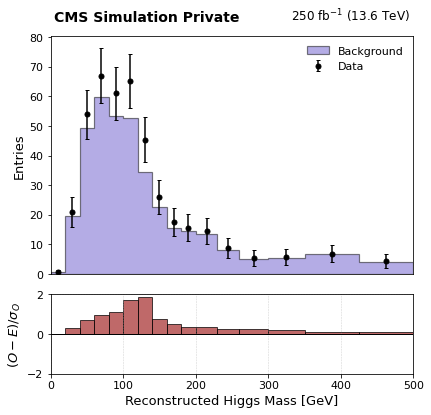


Bin-wise Complex Significance (Z_A):
  Bin Center (10.00): Z = 0.000
  Bin Center (30.00): Z = 0.078
  Bin Center (50.00): Z = 0.445
  Bin Center (70.00): Z = 0.805
  Bin Center (90.00): Z = 1.087
  Bin Center (110.00): Z = 2.673
  Bin Center (130.00): Z = 3.208
  Bin Center (150.00): Z = 0.469
  Bin Center (170.00): Z = 0.215
  Bin Center (190.00): Z = 0.095
  Bin Center (215.00): Z = 0.109
  Bin Center (245.00): Z = 0.050
  Bin Center (280.00): Z = 0.063
  Bin Center (325.00): Z = 0.030
  Bin Center (387.50): Z = 0.010
  Bin Center (462.50): Z = 0.010
Poisson Chi-squared (same bins): sqrt(χ²) = 3.05756
0 0.011144541263498344 0.6196338417092301 0.6307783829727285
1 1.2513114392905234 19.697300359634657 20.948611798925178
2 4.750446035595268 49.19999740661696 53.950443442212226
3 7.072501051676899 59.85838192178001 66.9308829734569
4 7.786294566395438 53.22393353795878 61.01022810435422
5 12.312208422213706 52.754897810798965 65.06710623301267
6 11.01807739566689 34.339188575510526 45

In [31]:
# === CMS-like Plot FINAL POLISHED ===
fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(4, 1, height_ratios=[3, 0.15, 1, 0.1], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[2], sharex=ax_top)

# --- Top Panel ---
# Background as step-filled histogram
ax_top.hist(
    bin_centers, bins=new_edges, weights=expected_values,
    histtype='stepfilled', color='slateblue', alpha=0.5,
    label='Background', edgecolor='black', linewidth=1.2, zorder=1
)

# Observed as black points with error bars
ax_top.errorbar(
    bin_centers, observed_values, yerr=observed_errors,
    fmt='o', color='black', label='Data', markersize=5, capsize=2, zorder=3
)

# CMS Title and Lumi text (outside plot so it doesn't collide with legend)
ax_top.text(0.01, 1.05, r"CMS Simulation Private", transform=ax_top.transAxes,
            fontsize=14, fontweight='bold', ha='left', va='bottom')
ax_top.text(0.01, 0.98, r"", transform=ax_top.transAxes,
            fontsize=12, style='italic', ha='left', va='bottom')
ax_top.text(0.99, 1.05, r"250 fb$^{-1}$ (13.6 TeV)", transform=ax_top.transAxes,
            fontsize=12, ha='right', va='bottom')

# Styling
ax_top.set_ylabel("Entries", fontsize=13)
ax_top.legend(fontsize=11, loc="best", frameon=False)
ax_top.set_xlim(0, 500)
ax_top.set_ylim(0, 1.2 * np.max(observed_values))
ax_top.tick_params(axis='both', labelsize=11)
ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False) # Remove x-axis labels on top

# No grid in top panel (CMS style)
ax_top.grid(False)

# --- Bottom Panel ---
ax_bottom.axhline(0, color='black', linewidth=1)
ax_bottom.bar(
    bin_centers, diff_norm, width=bin_widths, color='brown',
    edgecolor='black', alpha=0.7
)

# Styling
ax_bottom.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
ax_bottom.set_ylabel(r'$(O - E)/\sigma_O$', fontsize=13)
ax_bottom.set_ylim(-2, 2)
ax_bottom.set_xlim(0, 500)
ax_bottom.tick_params(axis='both', labelsize=11)

# Light dashed grid only in bottom panel
ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)

# Final adjust
fig.subplots_adjust(left=0.12, right=0.96, top=0.93, bottom=0.12, hspace=0.03)
fig.savefig("higgs_mass_plot.png", dpi=300, bbox_inches="tight")
plt.show()

chi2_poisson = 0  
s = 0
print("\nBin-wise Complex Significance (Z_A):")
for i in range(len(new_edges) - 1):
            S = signal_values[i]
            B = background_values[i]
            M = S + B  # Asimov data
            mu = B  

            if mu > 0 and M > 0:
              Z = 2 * (mu - M + M * np.log(M / mu))
              chi2_poisson += Z  
            elif M == 0:
              Z = 2 * mu
              chi2_poisson += Z  
            else:
              Z = 0  # Avoid invalid values

            significance_values.append(Z)
            bin_center = 0.5 * (new_edges[i] + new_edges[i + 1])
            print(f"  Bin Center ({bin_center:.2f}): Z = {Z:.3f}")

        
s = np.sqrt(chi2_poisson)
       
print(f"Poisson Chi-squared (same bins): sqrt(χ²) = {s:.5f}")

for i in range(len(new_edges) - 1):
    S = signal_values[i]
    B = background_values[i]
    M = S + B
    print(i, S, B, M)

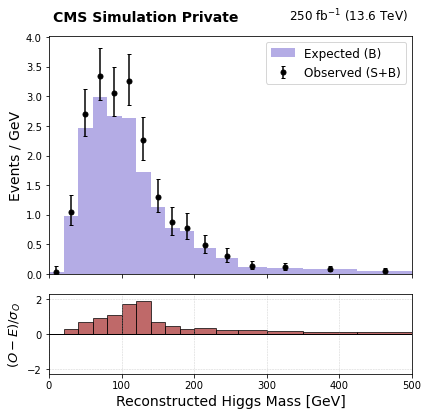

Poisson Asimov significance sqrt(χ²) = 3.05756


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from coffea.util import load
from hist import Hist
from scipy.stats import gamma

# ======================================================
# Garwood (asymmetric) Poisson errors
# ======================================================
def poisson_asymmetric_errors(n, cl=0.6827):
    alpha = 1 - cl
    lower = gamma.ppf(alpha / 2, n) if n > 0 else 0.0
    upper = gamma.ppf(1 - alpha / 2, n + 1)
    return n - lower, upper - n


# ======================================================
# Load histogram
# ======================================================
hist_data = load("/eos/user/p/piosifid/PocketCoffea/ANN_newCoffea/INF_DNN_new/17_Feb_dnn_try_preBpix_manydnncuts_055fnal/output_all.coffea")
variables = hist_data.get("variables", {})

hist_name = "Massreco_chosen_pair_higgs_mass_4"

# ======================================================
# Manual rebinning
# ======================================================
def rebin_1d_hist_manual(hist_obj, rebin_factor):
    axis = hist_obj.axes[0]
    edges = axis.edges
    n_bins = len(edges) - 1

    if n_bins % rebin_factor != 0:
        raise ValueError("Rebin factor does not divide number of bins")

    new_edges = edges[::rebin_factor]
    if edges[-1] not in new_edges:
        new_edges = np.append(new_edges, edges[-1])

    old_vals = hist_obj.values()[()]
    rebinned_vals = np.add.reduceat(old_vals, np.arange(0, len(old_vals), rebin_factor))

    return new_edges, rebinned_vals


# ======================================================
# Extract signal and background
# ======================================================
signal_dataset = "TTH_Hto2B"
background_dataset = "TTTo2L2Nu"

signal_hist = None
background_hist = None

for dataset, hist_dict in variables[hist_name].items():
    for variation, hist in hist_dict.items():
        if not isinstance(hist, Hist):
            continue

        if "cat" in [ax.name for ax in hist.axes]:
            hist = hist[{"cat": "baseline_all_atleast4bjets_dnn_pass"}]

        if "variation" in [ax.name for ax in hist.axes]:
            hist = hist[{"variation": "nominal"}]

        if dataset == signal_dataset:
            signal_hist = hist
        elif dataset == background_dataset:
            background_hist = hist

if signal_hist is None or background_hist is None:
    raise RuntimeError("Signal or background histogram not found")


# ======================================================
# Rebin + luminosity scaling
# ======================================================
new_edges, signal_values = rebin_1d_hist_manual(signal_hist, 1)
_, background_values = rebin_1d_hist_manual(background_hist, 1)

L_old = 9.69
L_new = 106.0
scale = L_new / L_old

signal_values *= scale
background_values *= scale

observed_values = signal_values + background_values
expected_values = background_values

bin_centers = 0.5 * (new_edges[:-1] + new_edges[1:])
bin_widths  = new_edges[1:] - new_edges[:-1]

# ======================================================
# Cut range
# ======================================================
mask = bin_centers <= 500

bin_centers = bin_centers[mask]
bin_widths = bin_widths[mask]
observed_values = observed_values[mask]
expected_values = expected_values[mask]
signal_values = signal_values[mask]
background_values = background_values[mask]


# ======================================================
# Bin-width normalization (TOP PANEL ONLY)
# ======================================================
observed_density = observed_values / bin_widths
expected_density = expected_values / bin_widths


# ======================================================
# Garwood asymmetric errors (bin-width normalized)
# ======================================================
err_low = np.zeros_like(observed_values)
err_up  = np.zeros_like(observed_values)

for i, n in enumerate(observed_values):
    lo, up = poisson_asymmetric_errors(n)
    err_low[i] = lo / bin_widths[i]
    err_up[i]  = up / bin_widths[i]


# ======================================================
# Bottom panel quantity (honestly labeled)
# ======================================================
pulls = np.zeros_like(signal_values)
for i in range(len(signal_values)):
    S = signal_values[i]
    B = background_values[i]
    pulls[i] = S / np.sqrt(B) if B > 0 else 0.0


# ======================================================
# CMS-style plot
# ======================================================
fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(4, 1, height_ratios=[3, 0.15, 1, 0.1], hspace=0.05)

ax_top = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[2], sharex=ax_top)

# --- Top panel ---
ax_top.bar(
    bin_centers,
    expected_density,
    width=bin_widths,
    color='slateblue',
     alpha=0.5,
    label="Expected (B)",
    linewidth=1
)

ax_top.errorbar(
    bin_centers,
    observed_density,
    yerr=[err_low, err_up],
    fmt="o",
    color="black",
    markersize=5,
    capsize=2,
    label="Observed (S+B)",
    zorder=3
)

ax_top.set_ylabel("Events / GeV", fontsize=14)
ax_top.set_xlim(0, 500)
ax_top.set_ylim(0, 1.2 * observed_density.max())
ax_top.legend(fontsize=12)
ax_top.grid(False)
plt.setp(ax_top.get_xticklabels(), visible=False)

# --- Bottom panel ---
ax_bottom.axhline(0, color="black", linewidth=1)
ax_bottom.bar(
    bin_centers,
    pulls,
    width=bin_widths,
    color="brown",
    edgecolor="black",
    alpha=0.7
)
# CMS Title and Lumi text (outside plot so it doesn't collide with legend)
ax_top.text(0.01, 1.05, r"CMS Simulation Private", transform=ax_top.transAxes,
            fontsize=14, fontweight='bold', ha='left', va='bottom')
ax_top.text(0.01, 0.98, r"", transform=ax_top.transAxes,
            fontsize=12, style='italic', ha='left', va='bottom')
ax_top.text(0.99, 1.05, r"250 fb$^{-1}$ (13.6 TeV)", transform=ax_top.transAxes,
            fontsize=12, ha='right', va='bottom')
ax_bottom.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=14)
ax_bottom.set_ylabel(r'$(O - E)/\sigma_O$', fontsize=13)
ax_bottom.set_xlim(0, 500)
ax_bottom.set_ylim(pulls.max() * (-1.2), pulls.max() * 1.2)
ax_bottom.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

fig.subplots_adjust(left=0.12, right=0.96, top=0.93, bottom=0.12)
plt.show()


# ======================================================
# Asimov Poisson chi^2
# ======================================================
chi2 = 0.0
for S, B in zip(signal_values, background_values):
    M = S + B
    mu = B
    if mu > 0 and M > 0:
        chi2 += 2 * (mu - M + M * np.log(M / mu))
    elif M == 0:
        chi2 += 2 * mu

print(f"Poisson Asimov significance sqrt(χ²) = {np.sqrt(chi2):.5f}")


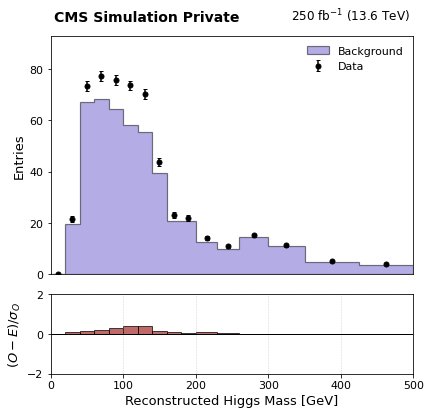


Bin-wise Complex Significance (Z_A):
  Bin Center (10.00): Z = 0.000
  Bin Center (30.00): Z = 0.173
  Bin Center (50.00): Z = 0.562
  Bin Center (70.00): Z = 1.175
  Bin Center (90.00): Z = 1.876
  Bin Center (110.00): Z = 3.718
  Bin Center (130.00): Z = 3.792
  Bin Center (150.00): Z = 0.471
  Bin Center (170.00): Z = 0.281
  Bin Center (190.00): Z = 0.068
  Bin Center (215.00): Z = 0.224
  Bin Center (245.00): Z = 0.101
  Bin Center (280.00): Z = 0.037
  Bin Center (325.00): Z = 0.010
  Bin Center (387.50): Z = 0.030
  Bin Center (462.50): Z = 0.028
Poisson Chi-squared (same bins): sqrt(χ²) = 3.54207
0 0.0 0.0 0.0
1 1.8749900423388033 19.647971246636295 21.5229612889751
2 6.2415093747147425 67.32705523243177 73.56856460714651
3 9.151657181232368 68.31224187578995 77.46389905702232
4 11.29570730917768 64.35666342865782 75.6523707378355
5 15.332985589375022 58.327032553597796 73.66001814297282
6 15.102492572478322 55.31914165700761 70.42163422948593
7 4.385999760480302 39.4364605509

In [8]:
# === CMS-like Plot FINAL POLISHED ===
fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(4, 1, height_ratios=[3, 0.15, 1, 0.1], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[2], sharex=ax_top)

# --- Top Panel ---
# Background as step-filled histogram
ax_top.hist(
    bin_centers, bins=new_edges, weights=expected_values,
    histtype='stepfilled', color='slateblue', alpha=0.5,
    label='Background', edgecolor='black', linewidth=1.2, zorder=1
)

# Observed as black points with error bars
ax_top.errorbar(
    bin_centers, observed_values, yerr=observed_errors,
    fmt='o', color='black', label='Data', markersize=5, capsize=2, zorder=3
)

# CMS Title and Lumi text (outside plot so it doesn't collide with legend)
ax_top.text(0.01, 1.05, r"CMS Simulation Private", transform=ax_top.transAxes,
            fontsize=14, fontweight='bold', ha='left', va='bottom')
ax_top.text(0.01, 0.98, r"", transform=ax_top.transAxes,
            fontsize=12, style='italic', ha='left', va='bottom')
ax_top.text(0.99, 1.05, r"250 fb$^{-1}$ (13.6 TeV)", transform=ax_top.transAxes,
            fontsize=12, ha='right', va='bottom')

# Styling
ax_top.set_ylabel("Entries", fontsize=13)
ax_top.legend(fontsize=11, loc="best", frameon=False)
ax_top.set_xlim(0, 500)
ax_top.set_ylim(0, 1.2 * np.max(observed_values))
ax_top.tick_params(axis='both', labelsize=11)
ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False) # Remove x-axis labels on top

# No grid in top panel (CMS style)
ax_top.grid(False)

# --- Bottom Panel ---
ax_bottom.axhline(0, color='black', linewidth=1)
ax_bottom.bar(
    bin_centers, diff_norm, width=bin_widths, color='brown',
    edgecolor='black', alpha=0.7
)

# Styling
ax_bottom.set_xlabel("Reconstructed Higgs Mass [GeV]", fontsize=13)
ax_bottom.set_ylabel(r'$(O - E)/\sigma_O$', fontsize=13)
ax_bottom.set_ylim(-2, 2)
ax_bottom.set_xlim(0, 500)
ax_bottom.tick_params(axis='both', labelsize=11)

# Light dashed grid only in bottom panel
ax_bottom.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)

# Final adjust
fig.subplots_adjust(left=0.12, right=0.96, top=0.93, bottom=0.12, hspace=0.03)
plt.show()
chi2_poisson = 0  
s = 0
print("\nBin-wise Complex Significance (Z_A):")
for i in range(len(new_edges) - 1):
            S = signal_values[i]
            B = background_values[i]
            M = S + B  # Asimov data
            mu = B  

            if mu > 0 and M > 0:
              Z = 2 * (mu - M + M * np.log(M / mu))
              chi2_poisson += Z  
            elif M == 0:
              Z = 2 * mu
              chi2_poisson += Z  
            else:
              Z = 0  # Avoid invalid values

            significance_values.append(Z)
            bin_center = 0.5 * (new_edges[i] + new_edges[i + 1])
            print(f"  Bin Center ({bin_center:.2f}): Z = {Z:.3f}")

        
s = np.sqrt(chi2_poisson)
       
print(f"Poisson Chi-squared (same bins): sqrt(χ²) = {s:.5f}")

for i in range(len(new_edges) - 1):
    S = signal_values[i]
    B = background_values[i]
    M = S + B
    print(i, S, B, M)